# 03 — Finalisasi Domain Indonesia dan Sensitivity Analysis Flash Drought

Notebook ini melanjutkan Notebook 02 tanpa menimpa hasilnya.

## Tujuan

1. Memakai **M0 broad screening** dari keluaran Notebook 02, sehingga M0 tidak dideteksi ulang.
2. Mewajibkan mask polygon Indonesia sebelum statistik nasional dihitung.
3. Menjalankan dua konfigurasi tambahan langsung dari persentil RZSM Notebook 01:
   - **M1 Baseline:** maksimum onset 5 pentad, minimum 1 pentad di bawah P20, recovery 1 pentad;
   - **M2 Persistent:** maksimum onset 5 pentad, minimum 3 pentad berturut-turut di bawah P20, recovery dikonfirmasi oleh 2 pentad berturut-turut ≥P20.
4. Membandingkan jumlah event, distribusi durasi, cakupan area, ranking tahun, cluster spasial, dan overlap antarmetode.
5. Menyimpan keluaran yang siap digunakan untuk Notebook 04.

## Prinsip interpretasi

- M0, M1, dan M2 adalah **konfigurasi operasional**, bukan tiga fenomena yang berbeda.
- Satu baris/grid flag adalah **grid-cell event**, bukan satu kejadian regional independen.
- Tahun 2025 tetap dihitung, tetapi secara default dikeluarkan dari ranking antartahun karena potensi bias *right censoring* di akhir periode.
- Notebook ini tidak menetapkan dampak pertanian dan tidak mendiagnosis mekanisme atmosfer.


## 0. Paket

Aktifkan instalasi hanya bila paket belum tersedia. Untuk hasil final, gunakan environment yang konsisten dan restart kernel setelah instalasi.


In [5]:
# %pip install numpy pandas xarray dask netCDF4 h5netcdf h5py bottleneck numba scipy matplotlib geopandas regionmask shapely


## 1. Impor dan versi paket


In [6]:
import sys

print("Python kernel:", sys.executable)

%pip install --upgrade regionmask geopandas shapely pyogrio

Python kernel: c:\Users\User\anaconda3\envs\era5\python.exe
Note: you may need to restart the kernel to use updated packages.


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  res = process_handler(cmd, _system_body)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [7]:
import regionmask
import geopandas as gpd
import shapely

print("regionmask :", regionmask.__version__)
print("geopandas  :", gpd.__version__)
print("shapely    :", shapely.__version__)
print("Natural Earth tersedia:")
print([
    name for name in dir(regionmask.defined_regions)
    if name.startswith("natural_earth")
])

regionmask : 0.13.0
geopandas  : 1.1.4
shapely    : 2.1.2
Natural Earth tersedia:
['natural_earth_v4_1_0', 'natural_earth_v5_0_0', 'natural_earth_v5_1_2']


In [8]:
from pathlib import Path
from itertools import combinations
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt

from scipy import ndimage
from numba import njit
from IPython.display import display

try:
    from dask.diagnostics import ProgressBar
except Exception:
    ProgressBar = None

warnings.filterwarnings("once")

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Xarray:", xr.__version__)


NumPy : 2.4.6
Pandas: 3.0.5
Xarray: 2026.7.0


## 2. Konfigurasi

Bagian yang biasanya perlu diubah:

- `NOTEBOOK01_DIR`
- `NOTEBOOK02_DIR`
- `OUTPUT_DIR`
- `INDONESIA_BOUNDARY_FILE` bila memakai polygon lokal.

File polygon lokal sebaiknya hanya berisi wilayah Indonesia. Jika berisi beberapa negara, isi `BOUNDARY_FILTER_FIELD` dan `BOUNDARY_FILTER_VALUE`.


In [9]:
NOTEBOOK01_DIR = Path(r"D:\ERA5_LAND\output_rzsm")
NOTEBOOK02_DIR = Path(r"D:\ERA5_LAND\output_fd_q1_revisi_final")
OUTPUT_DIR = Path(r"D:\ERA5_LAND\output_fd_03_sensitivity")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PERCENTILE_FILE = NOTEBOOK01_DIR / "rzsm_percentile_gringorten_1995_2025.nc"
RZSM_FILE = NOTEBOOK01_DIR / "rzsm_pentad_1995_2025.nc"

# Isi path eksplisit bila auto-discovery menemukan lebih dari satu file M0.
M0_DETECTION_FILE = None

# Polygon Indonesia: .shp, .gpkg, atau .geojson.
INDONESIA_BOUNDARY_FILE = None
BOUNDARY_FILTER_FIELD = None
BOUNDARY_FILTER_VALUE = None
TRY_BUILTIN_NATURAL_EARTH = True
REQUIRE_INDONESIA_MASK = True

# Opsional: file polygon pulau dengan satu kolom nama pulau.
ISLAND_BOUNDARY_FILE = None
ISLAND_NAME_FIELD = "island"

START_THRESHOLD = 40.0
DROUGHT_THRESHOLD = 20.0
MIN_DECLINE_RATE = 5.0
MIN_TOTAL_DURATION = 4
LONG_EVENT_PENTADS = 18

METHOD_CONFIGS = {
    "M0": {
        "label": "Broad screening — reused from Notebook 02",
        "source": "Notebook 02 output",
        "max_onset_pentads": None,
        "min_below_p20_pentads": 1,
        "recovery_consecutive_pentads": 1,
        "strict_monotonic": True,
    },
    "M1": {
        "label": "Baseline constrained",
        "source": "Rerun from Notebook 01 percentile",
        "max_onset_pentads": 5,
        "min_below_p20_pentads": 1,
        "recovery_consecutive_pentads": 1,
        "strict_monotonic": True,
    },
    "M2": {
        "label": "Persistent constrained",
        "source": "Rerun from Notebook 01 percentile",
        "max_onset_pentads": 5,
        "min_below_p20_pentads": 3,
        "recovery_consecutive_pentads": 2,
        "strict_monotonic": True,
    },
}

METHODS_TO_RUN = ["M1", "M2"]
FORCE_RERUN_M1_M2 = False

MIN_VALID_YEARS = 31
LAT_CHUNK = 15
LON_CHUNK = 40
TIME_CHUNK_OUTPUT = 73

CALCULATE_LARGEST_CORE_CLUSTER = True
RANKING_EXCLUDE_YEARS = [2025]
CANDIDATE_YEARS = [1997, 2003, 2004, 2015]
TOP_N_YEARS = 10

# Distribusi: nilai di atas batas terakhir digabung sebagai overflow.
ONSET_HISTOGRAM_MAX = 12
DURATION_HISTOGRAM_MAX = 60

FIGURE_DPI = 300
SAVE_PNG = True
SAVE_PDF = True

try:
    import h5netcdf  # noqa: F401
    NETCDF_ENGINE = "h5netcdf"
except Exception:
    NETCDF_ENGINE = "netcdf4"

print("Backend NetCDF:", NETCDF_ENGINE)


Backend NetCDF: h5netcdf


## 3. Fungsi penyimpanan dan validasi path


In [10]:
def save_figure(fig, stem):
    path = OUTPUT_DIR / stem
    if SAVE_PNG:
        fig.savefig(path.with_suffix(".png"), dpi=FIGURE_DPI, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    print("Figur tersimpan:", path)


def resolve_m0_detection_file():
    if M0_DETECTION_FILE is not None:
        path = Path(M0_DETECTION_FILE)
        if not path.exists():
            raise FileNotFoundError(f"M0_DETECTION_FILE tidak ditemukan: {path}")
        return path

    candidates = sorted(NOTEBOOK02_DIR.glob("fd_detection_primary_1995_2025_*.nc"))
    if not candidates:
        raise FileNotFoundError(
            "Keluaran M0 Notebook 02 tidak ditemukan di "
            f"{NOTEBOOK02_DIR}. Isi M0_DETECTION_FILE secara eksplisit."
        )

    bbox = [p for p in candidates if "bbox_screening" in p.name]
    if len(bbox) == 1:
        return bbox[0]
    if len(candidates) == 1:
        return candidates[0]

    raise RuntimeError(
        "Ditemukan lebih dari satu kandidat M0. Isi M0_DETECTION_FILE.\n"
        + "\n".join(str(p) for p in candidates)
    )


for required_file in [PERCENTILE_FILE, RZSM_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"File Notebook 01 tidak ditemukan: {required_file}\n"
            "Periksa NOTEBOOK01_DIR."
        )

M0_FILE_RESOLVED = resolve_m0_detection_file()
print("Input percentile:", PERCENTILE_FILE)
print("Input RZSM      :", RZSM_FILE)
print("Input M0        :", M0_FILE_RESOLVED)
print("Output          :", OUTPUT_DIR)


Input percentile: D:\ERA5_LAND\output_rzsm\rzsm_percentile_gringorten_1995_2025.nc
Input RZSM      : D:\ERA5_LAND\output_rzsm\rzsm_pentad_1995_2025.nc
Input M0        : D:\ERA5_LAND\output_fd_q1_revisi_final\fd_detection_primary_1995_2025_bbox_screening.nc
Output          : D:\ERA5_LAND\output_fd_03_sensitivity


## 4. Baca keluaran Notebook 01 dan bentuk sumbu waktu kontinu


In [11]:
# Buka secara lazy, lalu atur chunk setelah file dibuka.
ds_pct = xr.open_dataset(PERCENTILE_FILE)
ds_rzsm = xr.open_dataset(RZSM_FILE)

if "rzsm_percentile" not in ds_pct:
    raise KeyError(f"rzsm_percentile tidak ditemukan. Variabel: {list(ds_pct.data_vars)}")
if "rzsm" not in ds_rzsm:
    raise KeyError(f"rzsm tidak ditemukan. Variabel: {list(ds_rzsm.data_vars)}")

rzsm_percentile, rzsm_pentad = xr.align(
    ds_pct["rzsm_percentile"],
    ds_rzsm["rzsm"],
    join="exact",
)

required_dims = {"year", "pentad", "latitude", "longitude"}
for name, data_array in {
    "rzsm_percentile": rzsm_percentile,
    "rzsm": rzsm_pentad,
}.items():
    missing = required_dims - set(data_array.dims)
    if missing:
        raise ValueError(f"{name} kehilangan dimensi: {sorted(missing)}")

expected_years = np.arange(1995, 2026)
expected_pentads = np.arange(1, 74)
if not np.array_equal(rzsm_percentile["year"].values, expected_years):
    raise ValueError("Koordinat year harus persis 1995–2025.")
if not np.array_equal(rzsm_percentile["pentad"].values, expected_pentads):
    raise ValueError("Koordinat pentad harus persis 1–73.")

rzsm_percentile = rzsm_percentile.chunk({
    "year": -1,
    "pentad": -1,
    "latitude": LAT_CHUNK,
    "longitude": LON_CHUNK,
})
rzsm_pentad = rzsm_pentad.chunk({
    "year": -1,
    "pentad": -1,
    "latitude": LAT_CHUNK,
    "longitude": LON_CHUNK,
})

pct_stacked = rzsm_percentile.stack(time_index=("year", "pentad"))
rzsm_stacked = rzsm_pentad.stack(time_index=("year", "pentad"))

year_of_step = pct_stacked["year"].values.astype(np.int16)
pentad_of_step = pct_stacked["pentad"].values.astype(np.int16)
ntime = pct_stacked.sizes["time_index"]
simple_time_index = np.arange(ntime, dtype=np.int32)


def standardize_time_axis(data_array):
    return (
        data_array.reset_index("time_index", drop=True)
        .assign_coords(
            time_index=("time_index", simple_time_index),
            year=("time_index", year_of_step),
            pentad=("time_index", pentad_of_step),
        )
        .transpose("latitude", "longitude", "time_index")
        .chunk({
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
            "time_index": -1,
        })
    )

pct_time = standardize_time_axis(pct_stacked)
rzsm_time = standardize_time_axis(rzsm_stacked)

print("Bentuk percentile:", rzsm_percentile.shape)
print("Jumlah pentad kontinu:", ntime)
print("Awal/akhir:", (int(year_of_step[0]), int(pentad_of_step[0])), "->", (int(year_of_step[-1]), int(pentad_of_step[-1])))


Bentuk percentile: (31, 73, 171, 461)
Jumlah pentad kontinu: 2263
Awal/akhir: (1995, 1) -> (2025, 73)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


## 5. Mask polygon Indonesia — wajib untuk statistik final

Urutan pencarian mask:

1. polygon lokal;
2. Natural Earth melalui `regionmask`;
3. berhenti dengan error apabila keduanya gagal.

Natural Earth dapat digunakan untuk screening nasional. Polygon lokal beresolusi lebih tinggi tetap lebih baik untuk batas pesisir dan pulau kecil.


In [12]:
if "n_valid_years" in ds_pct:
    nvalid = ds_pct["n_valid_years"]
    reduce_dims = [d for d in nvalid.dims if d not in {"latitude", "longitude"}]
    valid_climatology = nvalid.min(reduce_dims) >= MIN_VALID_YEARS if reduce_dims else nvalid >= MIN_VALID_YEARS
else:
    valid_climatology = rzsm_percentile.notnull().all(("year", "pentad"))

valid_climatology = valid_climatology.transpose("latitude", "longitude")


def polygon_mask_from_local_file(path):
    import geopandas as gpd
    import regionmask

    boundary = gpd.read_file(path).to_crs("EPSG:4326")
    if BOUNDARY_FILTER_FIELD is not None:
        if BOUNDARY_FILTER_FIELD not in boundary.columns:
            raise KeyError(
                f"Kolom {BOUNDARY_FILTER_FIELD!r} tidak ada dalam polygon. "
                f"Kolom tersedia: {list(boundary.columns)}"
            )
        boundary = boundary.loc[
            boundary[BOUNDARY_FILTER_FIELD].astype(str) == str(BOUNDARY_FILTER_VALUE)
        ]

    boundary = boundary.loc[
        boundary.geometry.notnull() & ~boundary.geometry.is_empty
    ].copy()
    if boundary.empty:
        raise ValueError("Polygon lokal tidak memiliki geometri Indonesia yang valid.")

    geometry = (
        boundary.geometry.union_all()
        if hasattr(boundary.geometry, "union_all")
        else boundary.geometry.unary_union
    )
    regions = regionmask.Regions(
        outlines=[geometry],
        names=["Indonesia"],
        abbrevs=["IDN"],
        numbers=[1],
    )
    return regions.mask(
        rzsm_percentile["longitude"],
        rzsm_percentile["latitude"],
    ).notnull()


def polygon_mask_from_builtin_natural_earth():
    import regionmask

    errors = []
    version_names = [
        name for name in dir(regionmask.defined_regions)
        if name.startswith("natural_earth")
    ]
    version_names = sorted(version_names, reverse=True)

    for version_name in version_names:
        version = getattr(regionmask.defined_regions, version_name)
        for resolution_name in ["countries_10", "countries_50", "countries_110"]:
            countries = getattr(version, resolution_name, None)
            if countries is None:
                continue
            try:
                names = [str(name).strip().lower() for name in countries.names]
                matches = [i for i, name in enumerate(names) if name == "indonesia"]
                if not matches:
                    continue
                position = matches[0]
                region_number = int(countries.numbers[position])
                codes = countries.mask(
                    rzsm_percentile["longitude"],
                    rzsm_percentile["latitude"],
                )
                return codes == region_number, f"regionmask {version_name}.{resolution_name}"
            except Exception as exc:
                errors.append(f"{version_name}.{resolution_name}: {type(exc).__name__}: {exc}")

    raise RuntimeError(
        "Natural Earth Indonesia tidak dapat dibaca. "
        + (" | ".join(errors) if errors else "Koleksi Natural Earth tidak ditemukan.")
    )


polygon_mask = None
mask_source = None

if INDONESIA_BOUNDARY_FILE is not None:
    boundary_path = Path(INDONESIA_BOUNDARY_FILE)
    if not boundary_path.exists():
        raise FileNotFoundError(f"Polygon Indonesia tidak ditemukan: {boundary_path}")
    polygon_mask = polygon_mask_from_local_file(boundary_path)
    mask_source = str(boundary_path)
elif TRY_BUILTIN_NATURAL_EARTH:
    try:
        polygon_mask, mask_source = polygon_mask_from_builtin_natural_earth()
    except Exception as exc:
        print("Mask Natural Earth gagal:", exc)

if polygon_mask is None:
    message = (
        "Mask Indonesia tidak tersedia. Instal geopandas/regionmask atau isi "
        "INDONESIA_BOUNDARY_FILE. Statistik nasional tidak boleh dihitung tanpa mask."
    )
    if REQUIRE_INDONESIA_MASK:
        raise RuntimeError(message)
    print("PERINGATAN:", message)
    polygon_mask = xr.ones_like(valid_climatology, dtype=bool)
    mask_source = "bounding box fallback — not final"

valid_grid = (valid_climatology & polygon_mask).transpose("latitude", "longitude").compute()
if int(valid_grid.sum()) == 0:
    raise ValueError("Mask Indonesia menghasilkan nol grid valid.")

pct_time = pct_time.where(valid_grid)
rzsm_time = rzsm_time.where(valid_grid)

mask_dataset = xr.Dataset({
    "indonesia_valid_grid_mask": valid_grid.astype(np.int8),
})
mask_dataset.attrs.update({
    "title": "Indonesia valid-grid mask for flash drought sensitivity analysis",
    "source": str(mask_source),
    "minimum_valid_years": MIN_VALID_YEARS,
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
})
MASK_FILE = OUTPUT_DIR / "indonesia_valid_grid_mask_1995_2025.nc"
mask_dataset.to_netcdf(MASK_FILE, engine=NETCDF_ENGINE)

print("Sumber mask:", mask_source)
print("Grid Indonesia valid:", f"{int(valid_grid.sum()):,}")
print("Mask tersimpan:", MASK_FILE)


Sumber mask: regionmask natural_earth_v5_1_2.countries_10
Grid Indonesia valid: 14,857
Mask tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\indonesia_valid_grid_mask_1995_2025.nc


## 6. Tabel konfigurasi M0–M2


In [13]:
configuration_table = pd.DataFrame([
    {
        "method": method,
        **config,
        "start_threshold": START_THRESHOLD,
        "drought_threshold": DROUGHT_THRESHOLD,
        "min_decline_rate": MIN_DECLINE_RATE,
        "min_total_duration": MIN_TOTAL_DURATION,
    }
    for method, config in METHOD_CONFIGS.items()
])
display(configuration_table)
configuration_table.to_csv(OUTPUT_DIR / "fd_sensitivity_method_configuration.csv", index=False)


,method,label,source,max_onset_pentads,min_below_p20_pentads,recovery_consecutive_pentads,strict_monotonic,start_threshold,drought_threshold,min_decline_rate,min_total_duration
0,M0,Broad screening — reused from Notebook 02,Notebook 02 output,NaN,1,1,True,40.0,20.0,5.0,4
1,M1,Baseline constrained,Rerun from Notebook 01 percentile,5.0,1,1,True,40.0,20.0,5.0,4
2,M2,Persistent constrained,Rerun from Notebook 01 percentile,5.0,3,2,True,40.0,20.0,5.0,4


## 7. Fungsi deteksi untuk M1 dan M2

Perbedaan penting dari Notebook 02 adalah parameter `recovery_consecutive_pentads`.

- Recovery 1 pentad: terminasi pada pentad pertama yang kembali ≥P20.
- Recovery 2 pentad: terminasi pada pentad pertama dari dua pentad berturut-turut ≥P20.
- `min_below_p20_pentads` dihitung sebagai panjang **run berturut-turut pertama** di bawah P20 sejak crossing.


In [14]:
@njit
def detect_one_series(
    p,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
    max_total_duration,
    long_event_pentads,
):
    n = p.size

    phase = np.zeros(n, dtype=np.int8)
    event_id = np.zeros(n, dtype=np.int16)
    event_start = np.zeros(n, dtype=np.int8)
    threshold_crossing = np.zeros(n, dtype=np.int8)
    minimum_flag = np.zeros(n, dtype=np.int8)
    event_termination = np.zeros(n, dtype=np.int8)
    drought_core = np.zeros(n, dtype=np.int8)

    duration = np.full(n, -1, dtype=np.int16)
    onset_time = np.full(n, -1, dtype=np.int16)
    below_p20_duration = np.full(n, -1, dtype=np.int16)
    post_crossing_to_minimum = np.full(n, -1, dtype=np.int16)
    recovery_time = np.full(n, -1, dtype=np.int16)

    onset_speed = np.full(n, np.nan, dtype=np.float32)
    severity40 = np.full(n, np.nan, dtype=np.float32)
    severity20 = np.full(n, np.nan, dtype=np.float32)
    minimum_percentile = np.full(n, np.nan, dtype=np.float32)

    crossing_index_at_start = np.full(n, -1, dtype=np.int32)
    minimum_index_at_start = np.full(n, -1, dtype=np.int32)
    termination_index_at_start = np.full(n, -1, dtype=np.int32)
    event_class_at_start = np.zeros(n, dtype=np.int8)

    local_event_id = 0
    i = 0

    while i < n - 1:
        if np.isnan(p[i]) or np.isnan(p[i + 1]):
            i += 1
            continue

        if not (p[i] >= start_threshold and p[i + 1] < start_threshold):
            i += 1
            continue

        baseline = i
        crossing = -1
        j = baseline + 1

        while j < n:
            if np.isnan(p[j]) or np.isnan(p[j - 1]):
                break
            if max_onset_pentads > 0 and (j - baseline) > max_onset_pentads:
                break
            if strict_monotonic and not (p[j] < p[j - 1]):
                break
            if p[j] < drought_threshold:
                crossing = j
                break
            j += 1

        if crossing < 0:
            i += 1
            continue

        current_onset_time = crossing - baseline
        current_onset_speed = (p[baseline] - p[crossing]) / current_onset_time
        if current_onset_speed < min_decline_rate:
            i += 1
            continue

        termination = -1
        missing_during_event = False
        above_run = 0
        above_run_start = -1
        k = crossing + 1

        while k < n:
            if np.isnan(p[k]):
                missing_during_event = True
                break

            if p[k] >= drought_threshold:
                if above_run == 0:
                    above_run_start = k
                above_run += 1
                if above_run >= recovery_consecutive_pentads:
                    termination = above_run_start
                    break
            else:
                above_run = 0
                above_run_start = -1
            k += 1

        if missing_during_event:
            i = k + 1
            continue
        if termination < 0:
            break  # right-censored

        total_duration = termination - baseline

        initial_below_p20_run = 0
        q = crossing
        while q < termination and p[q] < drought_threshold:
            initial_below_p20_run += 1
            q += 1

        if total_duration < min_total_duration:
            i = termination
            continue
        if initial_below_p20_run < min_below_p20_pentads:
            i = termination
            continue
        if max_total_duration > 0 and total_duration > max_total_duration:
            i = termination
            continue

        min_value = p[crossing]
        min_index = crossing
        sev40 = 0.0
        sev20 = 0.0

        for q in range(baseline + 1, termination):
            if p[q] < min_value:
                min_value = p[q]
                min_index = q
            if p[q] < start_threshold:
                sev40 += start_threshold - p[q]
            if p[q] < drought_threshold:
                sev20 += drought_threshold - p[q]

        local_event_id += 1

        event_start[baseline] = 1
        threshold_crossing[crossing] = 1
        minimum_flag[min_index] = 1
        event_termination[termination] = 1

        duration[baseline] = total_duration
        onset_time[baseline] = current_onset_time
        below_p20_duration[baseline] = initial_below_p20_run
        post_crossing_to_minimum[baseline] = min_index - crossing
        recovery_time[baseline] = termination - min_index

        onset_speed[baseline] = current_onset_speed
        severity40[baseline] = sev40
        severity20[baseline] = sev20
        minimum_percentile[baseline] = min_value

        crossing_index_at_start[baseline] = crossing
        minimum_index_at_start[baseline] = min_index
        termination_index_at_start[baseline] = termination
        event_class_at_start[baseline] = (
            2 if long_event_pentads > 0 and total_duration > long_event_pentads else 1
        )

        for q in range(baseline, termination):
            event_id[q] = local_event_id
        for q in range(baseline, crossing + 1):
            phase[q] = 1
        for q in range(crossing + 1, min_index + 1):
            phase[q] = 2
        for q in range(min_index + 1, termination):
            phase[q] = 3
        for q in range(crossing, termination):
            if p[q] < drought_threshold:
                drought_core[q] = 1

        i = termination

    return (
        phase,
        event_id,
        event_start,
        threshold_crossing,
        minimum_flag,
        event_termination,
        drought_core,
        duration,
        onset_time,
        below_p20_duration,
        post_crossing_to_minimum,
        recovery_time,
        onset_speed,
        severity40,
        severity20,
        minimum_percentile,
        crossing_index_at_start,
        minimum_index_at_start,
        termination_index_at_start,
        event_class_at_start,
    )


@njit
def detect_block(
    p_block,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
    max_total_duration,
    long_event_pentads,
):
    original_shape = p_block.shape
    nt = original_shape[-1]
    npixel = p_block.size // nt
    flat = p_block.reshape((npixel, nt))

    phase = np.zeros((npixel, nt), dtype=np.int8)
    event_id = np.zeros((npixel, nt), dtype=np.int16)
    event_start = np.zeros((npixel, nt), dtype=np.int8)
    threshold_crossing = np.zeros((npixel, nt), dtype=np.int8)
    minimum_flag = np.zeros((npixel, nt), dtype=np.int8)
    event_termination = np.zeros((npixel, nt), dtype=np.int8)
    drought_core = np.zeros((npixel, nt), dtype=np.int8)

    duration = np.full((npixel, nt), -1, dtype=np.int16)
    onset_time = np.full((npixel, nt), -1, dtype=np.int16)
    below_p20_duration = np.full((npixel, nt), -1, dtype=np.int16)
    post_crossing_to_minimum = np.full((npixel, nt), -1, dtype=np.int16)
    recovery_time = np.full((npixel, nt), -1, dtype=np.int16)

    onset_speed = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity40 = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity20 = np.full((npixel, nt), np.nan, dtype=np.float32)
    minimum_percentile = np.full((npixel, nt), np.nan, dtype=np.float32)

    crossing_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    minimum_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    termination_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    event_class_at_start = np.zeros((npixel, nt), dtype=np.int8)

    for pixel in range(npixel):
        result = detect_one_series(
            flat[pixel],
            start_threshold,
            drought_threshold,
            min_decline_rate,
            min_total_duration,
            strict_monotonic,
            max_onset_pentads,
            min_below_p20_pentads,
            recovery_consecutive_pentads,
            max_total_duration,
            long_event_pentads,
        )

        phase[pixel] = result[0]
        event_id[pixel] = result[1]
        event_start[pixel] = result[2]
        threshold_crossing[pixel] = result[3]
        minimum_flag[pixel] = result[4]
        event_termination[pixel] = result[5]
        drought_core[pixel] = result[6]
        duration[pixel] = result[7]
        onset_time[pixel] = result[8]
        below_p20_duration[pixel] = result[9]
        post_crossing_to_minimum[pixel] = result[10]
        recovery_time[pixel] = result[11]
        onset_speed[pixel] = result[12]
        severity40[pixel] = result[13]
        severity20[pixel] = result[14]
        minimum_percentile[pixel] = result[15]
        crossing_index_at_start[pixel] = result[16]
        minimum_index_at_start[pixel] = result[17]
        termination_index_at_start[pixel] = result[18]
        event_class_at_start[pixel] = result[19]

    return (
        phase.reshape(original_shape),
        event_id.reshape(original_shape),
        event_start.reshape(original_shape),
        threshold_crossing.reshape(original_shape),
        minimum_flag.reshape(original_shape),
        event_termination.reshape(original_shape),
        drought_core.reshape(original_shape),
        duration.reshape(original_shape),
        onset_time.reshape(original_shape),
        below_p20_duration.reshape(original_shape),
        post_crossing_to_minimum.reshape(original_shape),
        recovery_time.reshape(original_shape),
        onset_speed.reshape(original_shape),
        severity40.reshape(original_shape),
        severity20.reshape(original_shape),
        minimum_percentile.reshape(original_shape),
        crossing_index_at_start.reshape(original_shape),
        minimum_index_at_start.reshape(original_shape),
        termination_index_at_start.reshape(original_shape),
        event_class_at_start.reshape(original_shape),
    )


## 8. Unit tests tambahan


In [15]:
def run_synthetic(
    values,
    max_onset=5,
    min_below=1,
    recovery=1,
    strict=True,
):
    return detect_one_series(
        np.asarray(values, dtype=np.float64),
        START_THRESHOLD,
        DROUGHT_THRESHOLD,
        MIN_DECLINE_RATE,
        MIN_TOTAL_DURATION,
        strict,
        max_onset,
        min_below,
        recovery,
        -1,
        LONG_EVENT_PENTADS,
    )

# Onset tepat 5 pentad diterima M1.
r = run_synthetic([60, 50, 39, 34, 29, 24, 19, 15, 22, 24])
assert int(r[2].sum()) == 1
assert int(r[8][r[2] == 1][0]) == 5

# Onset 6 pentad ditolak oleh MAX_ONSET=5.
r = run_synthetic([60, 45, 39, 35, 31, 27, 23, 19, 15, 22, 24])
assert int(r[2].sum()) == 0

# M2: tiga pentad awal berturut-turut <P20 dan recovery dua pentad diterima.
r = run_synthetic(
    [60, 45, 35, 27, 19, 17, 15, 21, 18, 22, 23, 50],
    min_below=3,
    recovery=2,
)
assert int(r[2].sum()) == 1
assert int(r[9][r[2] == 1][0]) == 3
assert int(np.flatnonzero(r[5] == 1)[0]) == 9

# Dua pentad awal <P20 ditolak M2.
r = run_synthetic(
    [60, 45, 35, 27, 19, 17, 22, 23, 50],
    min_below=3,
    recovery=2,
)
assert int(r[2].sum()) == 0

# Satu pentad ≥P20 tidak memutus event ketika recovery=2.
r = run_synthetic(
    [60, 45, 35, 27, 19, 17, 15, 21, 18, 16, 22, 23, 50],
    min_below=3,
    recovery=2,
)
assert int(np.flatnonzero(r[5] == 1)[0]) == 10
assert r[6][8] == 1 and r[6][9] == 1

# Right-censored event tidak diterima.
r = run_synthetic(
    [60, 45, 35, 27, 19, 17, 15],
    min_below=3,
    recovery=2,
)
assert int(r[2].sum()) == 0

# Minimum dapat terjadi tepat saat crossing.
r = run_synthetic(
    [60, 45, 35, 27, 10, 12, 15, 22, 23],
    min_below=3,
    recovery=2,
)
assert np.array_equal(np.flatnonzero(r[3] == 1), np.flatnonzero(r[4] == 1))

# Seri kontinu dapat melewati batas indeks yang mewakili pergantian tahun.
series = np.full(82, 55.0)
series[71:80] = [48, 39, 34, 28, 19, 16, 14, 22, 23]
r = run_synthetic(series, min_below=3, recovery=2)
assert int(r[2].sum()) == 1
assert int(np.flatnonzero(r[3] == 1)[0]) > 72

print("Semua unit tests Notebook 03 lulus.")


Semua unit tests Notebook 03 lulus.


## 9. Fungsi pembentukan dan penyimpanan output M1–M2


In [16]:
OUTPUT_NAMES = [
    "fd_phase",
    "fd_event_id",
    "fd_event_start",
    "fd_threshold_crossing",
    "fd_minimum_flag",
    "fd_event_termination",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "post_crossing_to_minimum_pentads_at_start",
    "recovery_time_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "severity_p20_at_start",
    "minimum_percentile_at_start",
    "crossing_index_at_start",
    "minimum_index_at_start",
    "termination_index_at_start",
    "event_class_at_start",
]

OUTPUT_DTYPES = [
    np.int8, np.int16, np.int8, np.int8, np.int8, np.int8, np.int8,
    np.int16, np.int16, np.int16, np.int16, np.int16,
    np.float32, np.float32, np.float32, np.float32,
    np.int32, np.int32, np.int32, np.int8,
]

INTEGER_TYPES = {
    "fd_phase": "int8",
    "fd_event_id": "int16",
    "fd_event_start": "int8",
    "fd_threshold_crossing": "int8",
    "fd_minimum_flag": "int8",
    "fd_event_termination": "int8",
    "fd_drought_core": "int8",
    "duration_pentads_at_start": "int16",
    "onset_time_pentads_at_start": "int16",
    "below_p20_pentads_at_start": "int16",
    "post_crossing_to_minimum_pentads_at_start": "int16",
    "recovery_time_pentads_at_start": "int16",
    "crossing_index_at_start": "int32",
    "minimum_index_at_start": "int32",
    "termination_index_at_start": "int32",
    "event_class_at_start": "int8",
}
FLOAT_VARIABLES = [
    "onset_speed_at_start",
    "severity_p40_at_start",
    "severity_p20_at_start",
    "minimum_percentile_at_start",
]


def standardize_detection_output(data_array, name):
    data_array = data_array.rename(name).transpose("time_index", "latitude", "longitude")
    if "time_index" in data_array.indexes and isinstance(data_array.indexes["time_index"], pd.MultiIndex):
        data_array = data_array.reset_index("time_index", drop=True)
    return data_array.assign_coords(
        time_index=("time_index", simple_time_index),
        year=("time_index", year_of_step),
        pentad=("time_index", pentad_of_step),
    )


def build_lazy_detection_dataset(method):
    config = METHOD_CONFIGS[method]
    max_onset = -1 if config["max_onset_pentads"] is None else int(config["max_onset_pentads"])

    result = xr.apply_ufunc(
        detect_block,
        pct_time,
        input_core_dims=[["time_index"]],
        output_core_dims=[["time_index"]] * len(OUTPUT_NAMES),
        vectorize=False,
        dask="parallelized",
        output_dtypes=OUTPUT_DTYPES,
        kwargs={
            "start_threshold": START_THRESHOLD,
            "drought_threshold": DROUGHT_THRESHOLD,
            "min_decline_rate": MIN_DECLINE_RATE,
            "min_total_duration": MIN_TOTAL_DURATION,
            "strict_monotonic": bool(config["strict_monotonic"]),
            "max_onset_pentads": max_onset,
            "min_below_p20_pentads": int(config["min_below_p20_pentads"]),
            "recovery_consecutive_pentads": int(config["recovery_consecutive_pentads"]),
            "max_total_duration": -1,
            "long_event_pentads": LONG_EVENT_PENTADS,
        },
        dask_gufunc_kwargs={"allow_rechunk": False},
    )

    standardized = [
        standardize_detection_output(data_array, name)
        for data_array, name in zip(result, OUTPUT_NAMES)
    ]
    dataset = xr.Dataset(dict(zip(OUTPUT_NAMES, standardized)))
    dataset["valid_grid_mask"] = valid_grid.astype(np.int8)

    dataset.attrs.update({
        "title": f"Flash drought sensitivity detection — {method}",
        "method": method,
        "method_label": config["label"],
        "period": "1995-2025",
        "start_threshold_percentile": START_THRESHOLD,
        "drought_threshold_percentile": DROUGHT_THRESHOLD,
        "minimum_mean_decline_rate_percentile_points_per_pentad": MIN_DECLINE_RATE,
        "minimum_total_duration_pentad_intervals": MIN_TOTAL_DURATION,
        "strict_monotonic_onset": str(config["strict_monotonic"]),
        "maximum_onset_pentads": str(config["max_onset_pentads"]),
        "minimum_initial_consecutive_below_p20_pentads": int(config["min_below_p20_pentads"]),
        "recovery_consecutive_pentads": int(config["recovery_consecutive_pentads"]),
        "long_event_classification_threshold_pentads": LONG_EVENT_PENTADS,
        "right_censored_events": "excluded",
        "spatial_mask_source": str(mask_source),
        "created_utc": str(pd.Timestamp.now(tz="UTC")),
    })
    return dataset


def detection_encoding():
    encoding = {}
    for variable, dtype in INTEGER_TYPES.items():
        encoding[variable] = {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
            "dtype": dtype,
            "_FillValue": None,
            "chunksizes": (TIME_CHUNK_OUTPUT, LAT_CHUNK, LON_CHUNK),
        }
    for variable in FLOAT_VARIABLES:
        encoding[variable] = {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
            "dtype": "float32",
            "_FillValue": np.float32(np.nan),
            "chunksizes": (TIME_CHUNK_OUTPUT, LAT_CHUNK, LON_CHUNK),
        }
    encoding["valid_grid_mask"] = {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "int8",
        "_FillValue": None,
        "chunksizes": (LAT_CHUNK, LON_CHUNK),
    }
    return encoding


def output_file_for_method(method):
    return OUTPUT_DIR / f"fd_detection_{method}_1995_2025_indonesia.nc"


def validate_existing_method_file(method, output_file):
    config = METHOD_CONFIGS[method]
    existing = xr.open_dataset(output_file, decode_cf=False)
    try:
        checks = {
            "method": method,
            "maximum_onset_pentads": str(config["max_onset_pentads"]),
            "minimum_initial_consecutive_below_p20_pentads": int(config["min_below_p20_pentads"]),
            "recovery_consecutive_pentads": int(config["recovery_consecutive_pentads"]),
            "spatial_mask_source": str(mask_source),
        }
        mismatches = []
        for key, expected in checks.items():
            found = existing.attrs.get(key)
            if str(found) != str(expected):
                mismatches.append(f"{key}: file={found!r}, expected={expected!r}")
        if mismatches:
            raise RuntimeError(
                f"{method}: file yang sudah ada memakai konfigurasi/mask berbeda. "
                "Set FORCE_RERUN_M1_M2=True.\n" + "\n".join(mismatches)
            )
    finally:
        existing.close()


def write_detection_method(method):
    output_file = output_file_for_method(method)
    if output_file.exists() and not FORCE_RERUN_M1_M2:
        validate_existing_method_file(method, output_file)
        print(f"{method}: memakai file yang sudah ada — {output_file}")
        return output_file
    if output_file.exists():
        output_file.unlink()

    print(f"{method}: membangun graph deteksi...")
    lazy_dataset = build_lazy_detection_dataset(method)
    print(f"{method}: menulis {output_file}")
    if ProgressBar is not None:
        with ProgressBar():
            lazy_dataset.to_netcdf(
                output_file,
                engine=NETCDF_ENGINE,
                encoding=detection_encoding(),
            )
    else:
        lazy_dataset.to_netcdf(
            output_file,
            engine=NETCDF_ENGINE,
            encoding=detection_encoding(),
        )
    print(f"{method}: selesai — {output_file.stat().st_size / 1e6:.1f} MB")
    return output_file


## 10. Jalankan M1 dan M2

M0 tidak dijalankan ulang. Bila file M1/M2 sudah ada dan `FORCE_RERUN_M1_M2=False`, notebook langsung memakainya.


In [17]:
method_files = {"M0": M0_FILE_RESOLVED}
for method in METHODS_TO_RUN:
    if method not in {"M1", "M2"}:
        raise ValueError(f"METHODS_TO_RUN hanya boleh berisi M1/M2, ditemukan {method}")
    method_files[method] = write_detection_method(method)

print("File metode:")
for method, path in method_files.items():
    print(method, "->", path)


M1: membangun graph deteksi...
M1: menulis D:\ERA5_LAND\output_fd_03_sensitivity\fd_detection_M1_1995_2025_indonesia.nc
[########################################] | 100% Completed | 86.26 s
M1: selesai — 76.6 MB
M2: membangun graph deteksi...
M2: menulis D:\ERA5_LAND\output_fd_03_sensitivity\fd_detection_M2_1995_2025_indonesia.nc
[########################################] | 100% Completed | 82.92 s
M2: selesai — 63.5 MB
File metode:
M0 -> D:\ERA5_LAND\output_fd_q1_revisi_final\fd_detection_primary_1995_2025_bbox_screening.nc
M1 -> D:\ERA5_LAND\output_fd_03_sensitivity\fd_detection_M1_1995_2025_indonesia.nc
M2 -> D:\ERA5_LAND\output_fd_03_sensitivity\fd_detection_M2_1995_2025_indonesia.nc


## 11. Buka dan validasi M0–M2


In [18]:
REQUIRED_DETECTION_VARIABLES = {
    "fd_phase",
    "fd_event_start",
    "fd_threshold_crossing",
    "fd_minimum_flag",
    "fd_event_termination",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "onset_speed_at_start",
    "event_class_at_start",
}


def open_and_validate_detection(method, path):
    dataset = xr.open_dataset(path, mask_and_scale=False)
    missing = REQUIRED_DETECTION_VARIABLES - set(dataset.data_vars)
    if missing:
        raise KeyError(f"{method} kehilangan variabel: {sorted(missing)}")

    for coordinate in ["time_index", "latitude", "longitude"]:
        if coordinate not in dataset.coords:
            raise KeyError(f"{method} kehilangan koordinat {coordinate}")

    if dataset.sizes["time_index"] != ntime:
        raise ValueError(f"{method}: panjang time_index tidak sama dengan Notebook 01.")
    if not np.array_equal(dataset["time_index"].values, simple_time_index):
        raise ValueError(f"{method}: koordinat time_index tidak identik.")
    if not np.array_equal(dataset["latitude"].values, rzsm_percentile["latitude"].values):
        raise ValueError(f"{method}: latitude tidak identik dengan Notebook 01.")
    if not np.array_equal(dataset["longitude"].values, rzsm_percentile["longitude"].values):
        raise ValueError(f"{method}: longitude tidak identik dengan Notebook 01.")

    if "year" in dataset.coords and not np.array_equal(dataset["year"].values, year_of_step):
        raise ValueError(f"{method}: koordinat year tidak identik.")
    if "pentad" in dataset.coords and not np.array_equal(dataset["pentad"].values, pentad_of_step):
        raise ValueError(f"{method}: koordinat pentad tidak identik.")

    dataset = dataset.assign_coords(
        year=("time_index", year_of_step),
        pentad=("time_index", pentad_of_step),
    ).chunk({
        "time_index": TIME_CHUNK_OUTPUT,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    })
    return dataset


datasets = {
    method: open_and_validate_detection(method, path)
    for method, path in method_files.items()
}

for method, dataset in datasets.items():
    print(method, dataset.attrs.get("title", "untitled"), dataset.sizes)


M0 Grid-cell flash drought detection from ERA5-Land RZSM percentile Frozen({'time_index': 2263, 'latitude': 171, 'longitude': 461})
M1 Flash drought sensitivity detection — M1 Frozen({'time_index': 2263, 'latitude': 171, 'longitude': 461})
M2 Flash drought sensitivity detection — M2 Frozen({'time_index': 2263, 'latitude': 171, 'longitude': 461})


## 12. QC setiap metode dan ringkasan keseluruhan


In [19]:
def compute_method_qc(method, dataset):
    start = (dataset["fd_event_start"] == 1).where(valid_grid, False)
    flag_variables = [
        "fd_event_start",
        "fd_threshold_crossing",
        "fd_minimum_flag",
        "fd_event_termination",
    ]
    flag_counts = {
        variable: int(dataset[variable].where(valid_grid, 0).sum().compute())
        for variable in flag_variables
    }
    if len(set(flag_counts.values())) != 1:
        raise AssertionError(f"{method}: flag tidak konsisten — {flag_counts}")

    event_count = flag_counts["fd_event_start"]
    if event_count == 0:
        raise RuntimeError(f"{method}: tidak ada event yang lolos.")

    affected_grids = int(start.any("time_index").sum().compute())
    prolonged_count = int(
        ((dataset["event_class_at_start"] == 2) & start).sum().compute()
    )

    min_speed = float(dataset["onset_speed_at_start"].where(start).min(skipna=True).compute())
    max_onset = int(dataset["onset_time_pentads_at_start"].where(start).max(skipna=True).compute())
    min_duration = int(dataset["duration_pentads_at_start"].where(start).min(skipna=True).compute())
    min_below = int(dataset["below_p20_pentads_at_start"].where(start).min(skipna=True).compute())
    mean_speed = float(
        dataset["onset_speed_at_start"].where(start, 0).sum().compute() / event_count
    )

    config = METHOD_CONFIGS[method]
    assert min_speed >= MIN_DECLINE_RATE - 1e-5
    assert min_duration >= MIN_TOTAL_DURATION
    assert min_below >= int(config["min_below_p20_pentads"])
    if config["max_onset_pentads"] is not None:
        assert max_onset <= int(config["max_onset_pentads"])

    return {
        "method": method,
        "label": config["label"],
        "gridcell_event_count": event_count,
        "affected_grid_count": affected_grids,
        "affected_grid_percent": 100.0 * affected_grids / int(valid_grid.sum()),
        "events_per_grid_per_year": event_count / int(valid_grid.sum()) / len(expected_years),
        "prolonged_event_count": prolonged_count,
        "prolonged_event_percent": 100.0 * prolonged_count / event_count,
        "minimum_onset_speed": min_speed,
        "mean_onset_speed": mean_speed,
        "maximum_onset_duration": max_onset,
        "minimum_total_duration": min_duration,
        "minimum_initial_below_p20_run": min_below,
    }


qc_rows = [compute_method_qc(method, dataset) for method, dataset in datasets.items()]
qc_summary = pd.DataFrame(qc_rows)
qc_summary.to_csv(OUTPUT_DIR / "fd_sensitivity_qc_summary.csv", index=False)
display(qc_summary)


,method,label,gridcell_event_count,affected_grid_count,affected_grid_percent,events_per_grid_per_year,prolonged_event_count,prolonged_event_percent,minimum_onset_speed,mean_onset_speed,maximum_onset_duration,minimum_total_duration,minimum_initial_below_p20_run
0,M0,Broad screening — reused from Notebook 02,822965,14852,99.966346,1.786852,27664,3.361504,5.141388,29.859596,7,4,1
1,M1,Baseline constrained,822856,14852,99.966346,1.786615,27649,3.360126,5.141388,29.862726,5,4,1
2,M2,Persistent constrained,578681,14851,99.959615,1.256453,34180,5.906536,5.141388,32.871441,5,4,3


## 13. Distribusi onset dan durasi tanpa membuat katalog jutaan baris


In [20]:
def integer_histogram(dataset, variable, maximum, method):
    start = (dataset["fd_event_start"] == 1).where(valid_grid, False)
    values = xr.where(start, dataset[variable], -999).data
    values = da.minimum(values, maximum + 1)
    edges = np.arange(-0.5, maximum + 2.5, 1.0)
    counts, edges = da.histogram(values, bins=edges)
    counts = counts.compute().astype(np.int64)

    records = []
    centers = ((edges[:-1] + edges[1:]) / 2).astype(int)
    total = counts.sum()
    for center, count in zip(centers, counts):
        if center < 0 or count == 0:
            continue
        label = f">{maximum}" if center == maximum + 1 else str(center)
        records.append({
            "method": method,
            "variable": variable,
            "bin_value": int(center),
            "bin_label": label,
            "count": int(count),
            "percent": 100.0 * count / total,
        })
    return records


distribution_rows = []
for method, dataset in datasets.items():
    distribution_rows.extend(integer_histogram(
        dataset,
        "onset_time_pentads_at_start",
        ONSET_HISTOGRAM_MAX,
        method,
    ))
    distribution_rows.extend(integer_histogram(
        dataset,
        "duration_pentads_at_start",
        DURATION_HISTOGRAM_MAX,
        method,
    ))

distribution_table = pd.DataFrame(distribution_rows)
distribution_table.to_csv(OUTPUT_DIR / "fd_sensitivity_distributions.csv", index=False)
display(distribution_table.head(15))


,method,variable,bin_value,bin_label,count,percent
0,M0,onset_time_pentads_at_start,1,1,244410,29.698711
1,M0,onset_time_pentads_at_start,2,2,422976,51.396596
2,M0,onset_time_pentads_at_start,3,3,132648,16.118304
3,M0,onset_time_pentads_at_start,4,4,20369,2.475075
4,M0,onset_time_pentads_at_start,5,5,2453,0.298069
5,M0,onset_time_pentads_at_start,6,6,108,0.013123
6,M0,onset_time_pentads_at_start,7,7,1,0.000122
7,M0,duration_pentads_at_start,4,4,294544,35.790586
8,M0,duration_pentads_at_start,5,5,191860,23.313264
9,M0,duration_pentads_at_start,6,6,112975,13.727801


## 14. Luas area berbobot latitude dan statistik pentad


In [21]:
latitude_weight = xr.DataArray(
    np.cos(np.deg2rad(rzsm_percentile["latitude"].values)),
    coords={"latitude": rzsm_percentile["latitude"]},
    dims=("latitude",),
)
area_weight = latitude_weight.broadcast_like(valid_grid).where(valid_grid)
total_area_weight = float(area_weight.sum())


def weighted_area_percent(mask, local_weight=area_weight, local_total=total_area_weight):
    return (
        100.0
        * (mask.astype(np.float32) * local_weight).sum(
            ("latitude", "longitude"), skipna=True
        )
        / local_total
    )


def compute_pentad_metrics(method, dataset):
    active = (dataset["fd_phase"] > 0).where(valid_grid, False)
    rapid = (dataset["fd_phase"] == 1).where(valid_grid, False)
    core = (dataset["fd_drought_core"] == 1).where(valid_grid, False)
    onset = (dataset["fd_event_start"] == 1).where(valid_grid, False)
    prolonged_start = (
        (dataset["event_class_at_start"] == 2) & onset
    )

    series = xr.Dataset({
        "active_event_area_percent": weighted_area_percent(active),
        "rapid_onset_area_percent": weighted_area_percent(rapid),
        "drought_core_area_percent": weighted_area_percent(core),
        "new_onset_area_percent": weighted_area_percent(onset),
        "event_start_count": onset.sum(("latitude", "longitude")),
        "prolonged_event_start_count": prolonged_start.sum(("latitude", "longitude")),
        "onset_speed_sum": dataset["onset_speed_at_start"].where(onset, 0).sum(
            ("latitude", "longitude")
        ),
    }).compute()

    frame = pd.DataFrame({
        "method": method,
        "time_index": simple_time_index,
        "year": year_of_step.astype(int),
        "pentad": pentad_of_step.astype(int),
    })
    for variable in series.data_vars:
        frame[variable] = series[variable].values
    return frame, core


pentad_frames = []
core_masks = {}
for method, dataset in datasets.items():
    print("Menghitung metrik pentad:", method)
    frame, core = compute_pentad_metrics(method, dataset)
    pentad_frames.append(frame)
    core_masks[method] = core

pentad_metrics = pd.concat(pentad_frames, ignore_index=True)


Menghitung metrik pentad: M0
Menghitung metrik pentad: M1
Menghitung metrik pentad: M2


## 15. Largest connected drought-core cluster


In [22]:
def largest_cluster_percent(mask_2d, weight_2d, total_weight):
    mask_2d = np.asarray(mask_2d, dtype=bool)
    if not mask_2d.any():
        return 0.0

    labels, nlabels = ndimage.label(
        mask_2d,
        structure=np.ones((3, 3), dtype=np.int8),
    )
    if nlabels == 0:
        return 0.0

    cluster_weight = np.bincount(
        labels.ravel(),
        weights=np.where(mask_2d, weight_2d, 0.0).ravel(),
    )
    return 100.0 * cluster_weight[1:].max() / total_weight


pentad_metrics["largest_core_cluster_percent"] = np.nan

if CALCULATE_LARGEST_CORE_CLUSTER:
    weight_values = area_weight.fillna(0).values

    for method in datasets:
        values = np.zeros(ntime, dtype=np.float32)
        core = core_masks[method]

        for year_value in expected_years:
            indices = np.flatnonzero(year_of_step == year_value)
            core_year = core.isel(time_index=indices).compute().values
            for local_index, global_index in enumerate(indices):
                values[global_index] = largest_cluster_percent(
                    core_year[local_index],
                    weight_values,
                    total_area_weight,
                )
            print(f"Cluster {method}: {year_value} selesai")

        selector = pentad_metrics["method"] == method
        pentad_metrics.loc[selector, "largest_core_cluster_percent"] = values
else:
    print("Largest cluster dilewati karena CALCULATE_LARGEST_CORE_CLUSTER=False")

PENTAD_FILE = OUTPUT_DIR / "fd_sensitivity_pentad_metrics_1995_2025.csv"
pentad_metrics.to_csv(PENTAD_FILE, index=False)
print("Tersimpan:", PENTAD_FILE)


Cluster M0: 1995 selesai
Cluster M0: 1996 selesai
Cluster M0: 1997 selesai
Cluster M0: 1998 selesai
Cluster M0: 1999 selesai
Cluster M0: 2000 selesai
Cluster M0: 2001 selesai
Cluster M0: 2002 selesai
Cluster M0: 2003 selesai
Cluster M0: 2004 selesai
Cluster M0: 2005 selesai
Cluster M0: 2006 selesai
Cluster M0: 2007 selesai
Cluster M0: 2008 selesai
Cluster M0: 2009 selesai
Cluster M0: 2010 selesai
Cluster M0: 2011 selesai
Cluster M0: 2012 selesai
Cluster M0: 2013 selesai
Cluster M0: 2014 selesai
Cluster M0: 2015 selesai
Cluster M0: 2016 selesai
Cluster M0: 2017 selesai
Cluster M0: 2018 selesai
Cluster M0: 2019 selesai
Cluster M0: 2020 selesai
Cluster M0: 2021 selesai
Cluster M0: 2022 selesai
Cluster M0: 2023 selesai
Cluster M0: 2024 selesai
Cluster M0: 2025 selesai
Cluster M1: 1995 selesai
Cluster M1: 1996 selesai
Cluster M1: 1997 selesai
Cluster M1: 1998 selesai
Cluster M1: 1999 selesai
Cluster M1: 2000 selesai
Cluster M1: 2001 selesai
Cluster M1: 2002 selesai
Cluster M1: 2003 selesai


## 16. Statistik tahunan dan ranking


In [23]:
annual_rows = []

for (method, year_value), group in pentad_metrics.groupby(["method", "year"], sort=True):
    event_count = int(group["event_start_count"].sum())
    prolonged_count = int(group["prolonged_event_start_count"].sum())
    speed_sum = float(group["onset_speed_sum"].sum())

    row = {
        "method": method,
        "year": int(year_value),
        "ranking_eligible": int(year_value) not in set(RANKING_EXCLUDE_YEARS),
        "gridcell_event_count": event_count,
        "prolonged_event_count": prolonged_count,
        "prolonged_event_percent": (
            100.0 * prolonged_count / event_count if event_count else np.nan
        ),
        "mean_onset_speed": speed_sum / event_count if event_count else np.nan,
        "maximum_active_event_area_percent": group["active_event_area_percent"].max(),
        "maximum_rapid_onset_area_percent": group["rapid_onset_area_percent"].max(),
        "maximum_drought_core_area_percent": group["drought_core_area_percent"].max(),
        "maximum_new_onset_area_percent": group["new_onset_area_percent"].max(),
        "integrated_drought_core_area_percent_pentad": group["drought_core_area_percent"].sum(),
        "maximum_largest_core_cluster_percent": group["largest_core_cluster_percent"].max(),
        "pentad_of_maximum_drought_core_area": int(
            group.loc[group["drought_core_area_percent"].idxmax(), "pentad"]
        ),
        "pentad_of_maximum_new_onset_area": int(
            group.loc[group["new_onset_area_percent"].idxmax(), "pentad"]
        ),
    }
    annual_rows.append(row)

annual_metrics = pd.DataFrame(annual_rows)
rank_columns = [
    "maximum_drought_core_area_percent",
    "maximum_new_onset_area_percent",
    "integrated_drought_core_area_percent_pentad",
    "maximum_largest_core_cluster_percent",
]

for rank_column in rank_columns:
    annual_metrics[f"rank_{rank_column}"] = pd.Series(pd.NA, index=annual_metrics.index, dtype="Int64")
    for method in datasets:
        selector = (
            (annual_metrics["method"] == method)
            & annual_metrics["ranking_eligible"]
        )
        ranks = annual_metrics.loc[selector, rank_column].rank(
            method="min", ascending=False
        ).astype("Int64")
        annual_metrics.loc[selector, f"rank_{rank_column}"] = ranks

annual_metrics["candidate_rank"] = annual_metrics[
    "rank_maximum_drought_core_area_percent"
]

ANNUAL_FILE = OUTPUT_DIR / "fd_sensitivity_annual_metrics_1995_2025.csv"
annual_metrics.to_csv(ANNUAL_FILE, index=False)

ranking_table = (
    annual_metrics[annual_metrics["ranking_eligible"]]
    .sort_values(["method", "candidate_rank", "year"])
)
TOP10_FILE = OUTPUT_DIR / "fd_sensitivity_top10_years.csv"
ranking_table.groupby("method", group_keys=False).head(TOP_N_YEARS).to_csv(TOP10_FILE, index=False)

display(
    ranking_table.groupby("method", group_keys=False).head(TOP_N_YEARS)[
        [
            "method", "candidate_rank", "year",
            "maximum_drought_core_area_percent",
            "maximum_new_onset_area_percent",
            "maximum_largest_core_cluster_percent",
            "gridcell_event_count",
        ]
    ]
)


,method,candidate_rank,year,maximum_drought_core_area_percent,maximum_new_onset_area_percent,maximum_largest_core_cluster_percent,gridcell_event_count
8,M0,1,2003,82.068881,34.006767,26.873425,33193
2,M0,2,1997,72.667859,27.568804,23.312143,30650
20,M0,3,2015,70.592732,26.264142,26.022757,30401
19,M0,4,2014,59.677940,24.635745,24.683565,26463
13,M0,5,2008,54.994099,19.929853,21.386393,27551
14,M0,6,2009,54.723767,23.252089,19.724800,31991
6,M0,7,2001,52.655535,19.523841,19.759472,31141
7,M0,8,2002,52.593331,26.740870,24.088268,37186
9,M0,9,2004,51.878796,38.812570,21.737268,42162
1,M0,10,1996,51.662165,33.260486,20.993782,37301


## 17. Ringkasan ranking kandidat utama


In [24]:
candidate_rows = annual_metrics[
    annual_metrics["year"].isin(CANDIDATE_YEARS)
].copy()

candidate_summary = candidate_rows[
    [
        "method",
        "year",
        "candidate_rank",
        "maximum_drought_core_area_percent",
        "maximum_new_onset_area_percent",
        "maximum_largest_core_cluster_percent",
        "integrated_drought_core_area_percent_pentad",
        "gridcell_event_count",
        "prolonged_event_percent",
    ]
].sort_values(["year", "method"])

candidate_summary.to_csv(OUTPUT_DIR / "fd_sensitivity_candidate_years.csv", index=False)
display(candidate_summary)

# Tahun yang masuk top-5 di semua metode.
top5_sets = {}
for method in datasets:
    top5_sets[method] = set(
        ranking_table[ranking_table["method"] == method]
        .nsmallest(5, "candidate_rank")["year"]
        .astype(int)
    )

robust_top5_years = sorted(set.intersection(*top5_sets.values()))
print("Top-5 per metode:", top5_sets)
print("Tahun yang berada dalam top-5 semua metode:", robust_top5_years)


,method,year,candidate_rank,maximum_drought_core_area_percent,maximum_new_onset_area_percent,maximum_largest_core_cluster_percent,integrated_drought_core_area_percent_pentad,gridcell_event_count,prolonged_event_percent
2,M0,1997,2,72.667859,27.568804,23.312143,2581.661746,30650,21.233279
33,M1,1997,2,72.667859,27.568804,23.312143,2580.950147,30646,21.222998
64,M2,1997,2,72.882886,24.778663,24.673906,2789.218926,25256,30.622426
8,M0,2003,1,82.068881,34.006767,26.873425,1250.860048,33193,5.681921
39,M1,2003,1,82.068881,34.006767,26.873425,1250.819967,33190,5.682434
70,M2,2003,1,82.472033,33.548783,27.344976,1223.327905,26490,8.259721
9,M0,2004,9,51.878796,38.812570,21.737268,1392.615524,42162,1.456288
40,M1,2004,9,51.872052,38.812570,21.737268,1392.454061,42152,1.456633
71,M2,2004,5,53.736786,32.151677,18.647175,1363.410300,32946,2.786378
20,M0,2015,3,70.592732,26.264142,26.022757,1512.001503,30401,14.088352


Top-5 per metode: {'M0': {1997, 2003, 2008, 2014, 2015}, 'M1': {1997, 2003, 2008, 2014, 2015}, 'M2': {1997, 2003, 2004, 2014, 2015}}
Tahun yang berada dalam top-5 semua metode: [1997, 2003, 2014, 2015]


## 18. Overlap antarmetode


In [25]:
def jaccard_metrics(mask_a, mask_b):
    intersection = int((mask_a & mask_b).sum().compute())
    union = int((mask_a | mask_b).sum().compute())
    count_a = int(mask_a.sum().compute())
    count_b = int(mask_b.sum().compute())
    return {
        "intersection": intersection,
        "union": union,
        "count_a": count_a,
        "count_b": count_b,
        "jaccard": intersection / union if union else np.nan,
        "retention_of_a": intersection / count_a if count_a else np.nan,
        "retention_of_b": intersection / count_b if count_b else np.nan,
    }


overlap_rows = []
for method_a, method_b in combinations(datasets.keys(), 2):
    ds_a = datasets[method_a]
    ds_b = datasets[method_b]

    masks = {
        "ever_affected_grid": (
            (ds_a["fd_event_start"] == 1).where(valid_grid, False).any("time_index"),
            (ds_b["fd_event_start"] == 1).where(valid_grid, False).any("time_index"),
        ),
        "event_start_spatiotemporal": (
            (ds_a["fd_event_start"] == 1).where(valid_grid, False),
            (ds_b["fd_event_start"] == 1).where(valid_grid, False),
        ),
        "drought_core_spatiotemporal": (
            (ds_a["fd_drought_core"] == 1).where(valid_grid, False),
            (ds_b["fd_drought_core"] == 1).where(valid_grid, False),
        ),
    }

    for metric, (mask_a, mask_b) in masks.items():
        values = jaccard_metrics(mask_a, mask_b)
        overlap_rows.append({
            "method_a": method_a,
            "method_b": method_b,
            "metric": metric,
            **values,
        })
        print(method_a, method_b, metric, "selesai")

overlap_table = pd.DataFrame(overlap_rows)
overlap_table.to_csv(OUTPUT_DIR / "fd_sensitivity_overlap.csv", index=False)
display(overlap_table)


M0 M1 ever_affected_grid selesai
M0 M1 event_start_spatiotemporal selesai
M0 M1 drought_core_spatiotemporal selesai
M0 M2 ever_affected_grid selesai
M0 M2 event_start_spatiotemporal selesai
M0 M2 drought_core_spatiotemporal selesai
M1 M2 ever_affected_grid selesai
M1 M2 event_start_spatiotemporal selesai
M1 M2 drought_core_spatiotemporal selesai


,method_a,method_b,metric,intersection,union,count_a,count_b,jaccard,retention_of_a,retention_of_b
0,M0,M1,ever_affected_grid,14852,14852,14852,14852,1.000000,1.000000,1.000000
1,M0,M1,event_start_spatiotemporal,822856,822965,822965,822856,0.999868,0.999868,1.000000
2,M0,M1,drought_core_spatiotemporal,3857644,3858337,3858337,3857644,0.999820,0.999820,1.000000
3,M0,M2,ever_affected_grid,14851,14852,14852,14851,0.999933,0.999933,1.000000
4,M0,M2,event_start_spatiotemporal,578681,822965,822965,578681,0.703166,0.703166,1.000000
5,M0,M2,drought_core_spatiotemporal,3419156,4078432,3858337,3639251,0.838351,0.886173,0.939522
6,M1,M2,ever_affected_grid,14851,14852,14852,14851,0.999933,0.999933,1.000000
7,M1,M2,event_start_spatiotemporal,578681,822856,822856,578681,0.703259,0.703259,1.000000
8,M1,M2,drought_core_spatiotemporal,3419156,4077739,3857644,3639251,0.838493,0.886333,0.939522


## 19. Statistik per pulau — opsional

Bagian ini hanya berjalan bila `ISLAND_BOUNDARY_FILE` tersedia. Notebook tidak memakai kotak koordinat buatan karena batas tersebut tidak cukup kuat untuk statistik final.


In [26]:
island_rows = []

if ISLAND_BOUNDARY_FILE is None:
    print("Statistik pulau dilewati: ISLAND_BOUNDARY_FILE belum diisi.")
else:
    import geopandas as gpd
    import regionmask

    island_path = Path(ISLAND_BOUNDARY_FILE)
    if not island_path.exists():
        raise FileNotFoundError(island_path)

    islands = gpd.read_file(island_path).to_crs("EPSG:4326")
    if ISLAND_NAME_FIELD not in islands.columns:
        raise KeyError(
            f"Kolom {ISLAND_NAME_FIELD!r} tidak ada. Kolom: {list(islands.columns)}"
        )
    islands = islands.loc[
        islands.geometry.notnull() & ~islands.geometry.is_empty
    ].copy()

    names = []
    geometries = []
    for name, group in islands.groupby(ISLAND_NAME_FIELD):
        geometry = (
            group.geometry.union_all()
            if hasattr(group.geometry, "union_all")
            else group.geometry.unary_union
        )
        names.append(str(name))
        geometries.append(geometry)

    numbers = list(range(1, len(names) + 1))
    island_regions = regionmask.Regions(
        outlines=geometries,
        names=names,
        abbrevs=names,
        numbers=numbers,
    )
    island_code = island_regions.mask(
        rzsm_percentile["longitude"],
        rzsm_percentile["latitude"],
    )

    for name, number in zip(names, numbers):
        island_valid = valid_grid & (island_code == number)
        grid_count = int(island_valid.sum())
        if grid_count == 0:
            continue
        island_weight = latitude_weight.broadcast_like(island_valid).where(island_valid)
        island_total = float(island_weight.sum())

        for method, dataset in datasets.items():
            start = (dataset["fd_event_start"] == 1).where(island_valid, False)
            core = (dataset["fd_drought_core"] == 1).where(island_valid, False)
            event_count = int(start.sum().compute())
            affected = int(start.any("time_index").sum().compute())
            max_core = float(
                weighted_area_percent(core, island_weight, island_total).max().compute()
            )
            island_rows.append({
                "island": name,
                "method": method,
                "valid_grid_count": grid_count,
                "gridcell_event_count": event_count,
                "affected_grid_percent": 100.0 * affected / grid_count,
                "maximum_drought_core_area_percent": max_core,
            })

    island_table = pd.DataFrame(island_rows)
    island_table.to_csv(OUTPUT_DIR / "fd_sensitivity_island_summary.csv", index=False)
    display(island_table)


Statistik pulau dilewati: ISLAND_BOUNDARY_FILE belum diisi.


## 20. Figur — jumlah event dan grid terdampak


Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_event_count_by_method


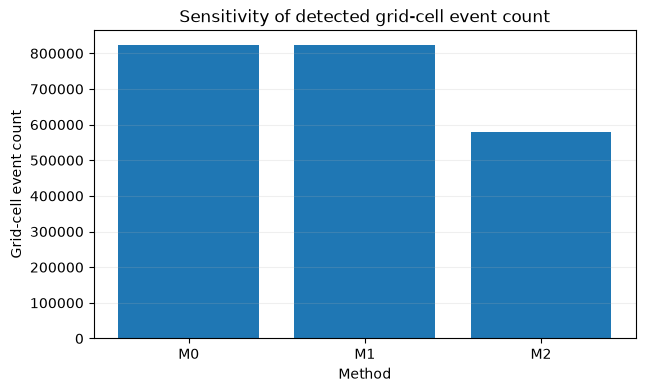

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_affected_grid_percent_by_method


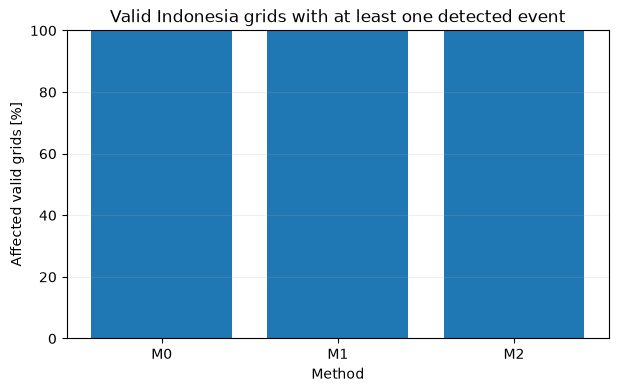

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(qc_summary["method"], qc_summary["gridcell_event_count"])
ax.set(
    xlabel="Method",
    ylabel="Grid-cell event count",
    title="Sensitivity of detected grid-cell event count",
)
ax.ticklabel_format(axis="y", style="plain")
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "figure_event_count_by_method")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(qc_summary["method"], qc_summary["affected_grid_percent"])
ax.set(
    xlabel="Method",
    ylabel="Affected valid grids [%]",
    title="Valid Indonesia grids with at least one detected event",
    ylim=(0, 100),
)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "figure_affected_grid_percent_by_method")
plt.show()


## 21. Figur — distribusi onset dan durasi


Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_distribution_onset_time_pentads_at_start


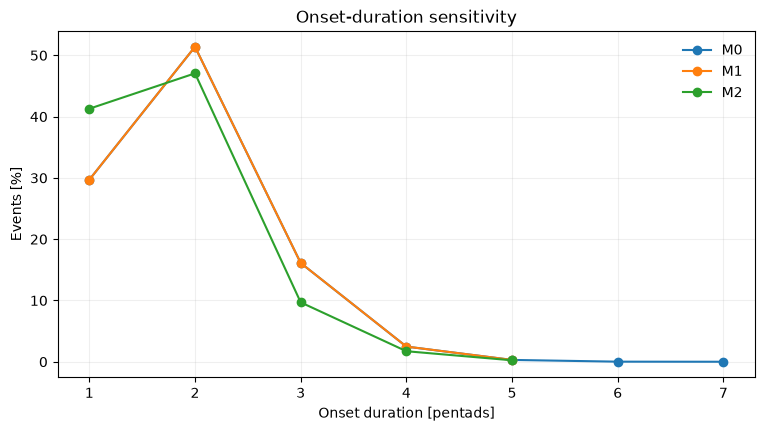

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_distribution_duration_pentads_at_start


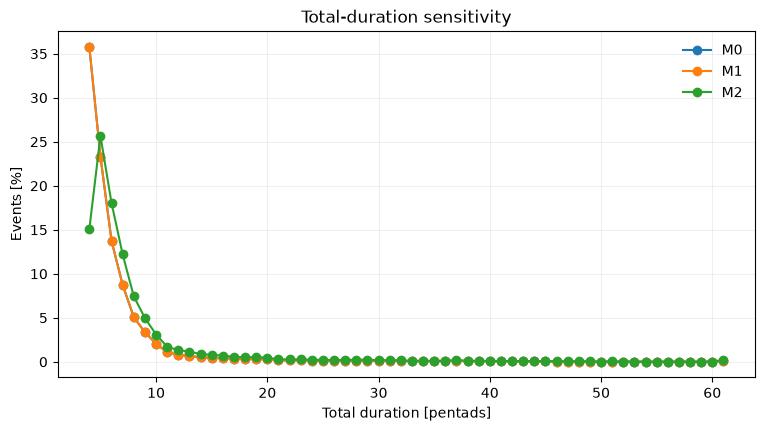

In [28]:
for variable, title, xlabel in [
    ("onset_time_pentads_at_start", "Onset-duration sensitivity", "Onset duration [pentads]"),
    ("duration_pentads_at_start", "Total-duration sensitivity", "Total duration [pentads]"),
]:
    subset = distribution_table[distribution_table["variable"] == variable]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for method in datasets:
        method_data = subset[subset["method"] == method].sort_values("bin_value")
        ax.plot(method_data["bin_value"], method_data["percent"], marker="o", label=method)
    ax.set(xlabel=xlabel, ylabel="Events [%]", title=title)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    save_figure(fig, f"figure_distribution_{variable}")
    plt.show()


## 22. Figur — ranking tahunan dan tahun kandidat


Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_annual_maximum_drought_core_area


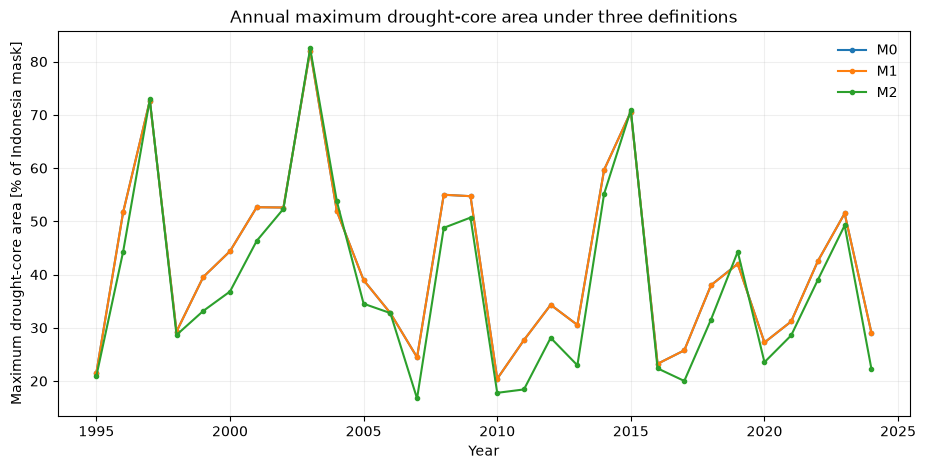

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_candidate_year_1997_core_area


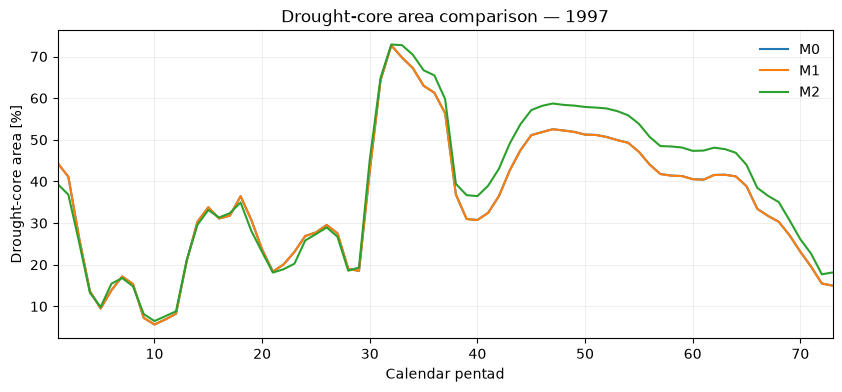

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_candidate_year_2003_core_area


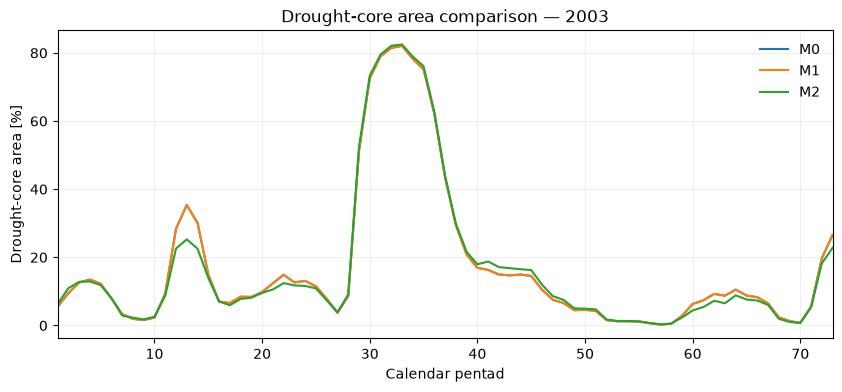

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_candidate_year_2004_core_area


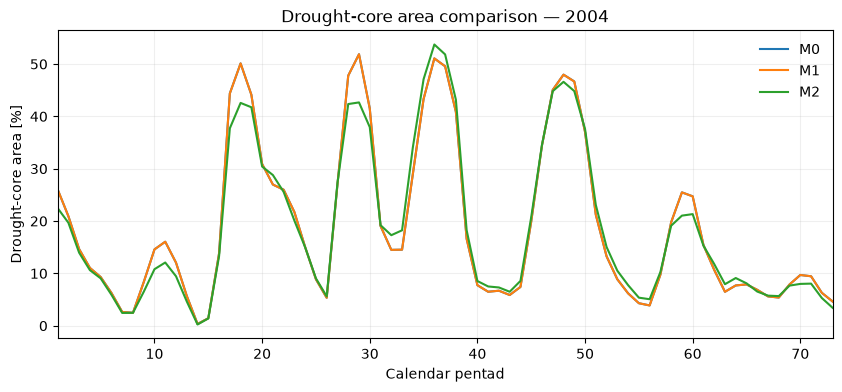

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_candidate_year_2015_core_area


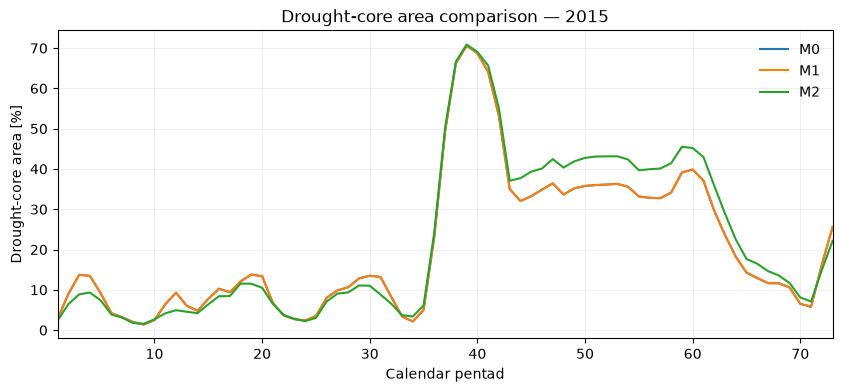

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
for method in datasets:
    method_data = annual_metrics[
        (annual_metrics["method"] == method)
        & annual_metrics["ranking_eligible"]
    ].sort_values("year")
    ax.plot(
        method_data["year"],
        method_data["maximum_drought_core_area_percent"],
        marker="o",
        markersize=3,
        label=method,
    )
ax.set(
    xlabel="Year",
    ylabel="Maximum drought-core area [% of Indonesia mask]",
    title="Annual maximum drought-core area under three definitions",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
save_figure(fig, "figure_annual_maximum_drought_core_area")
plt.show()

for selected_year in CANDIDATE_YEARS:
    subset = pentad_metrics[pentad_metrics["year"] == selected_year]
    if subset.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    for method in datasets:
        method_data = subset[subset["method"] == method].sort_values("pentad")
        ax.plot(
            method_data["pentad"],
            method_data["drought_core_area_percent"],
            label=method,
        )
    ax.set(
        xlabel="Calendar pentad",
        ylabel="Drought-core area [%]",
        title=f"Drought-core area comparison — {selected_year}",
        xlim=(1, 73),
    )
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    save_figure(fig, f"figure_candidate_year_{selected_year}_core_area")
    plt.show()


## 23. Figur — overlap dan frekuensi grid


Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_drought_core_jaccard


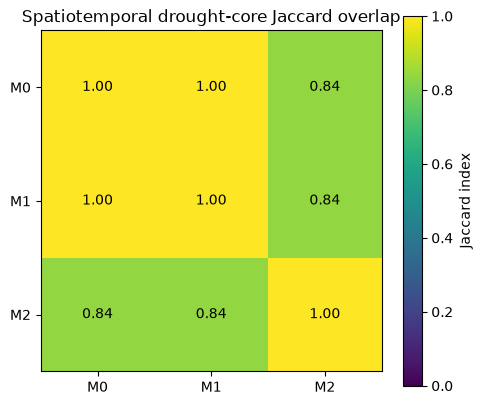

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_event_frequency_map_M0


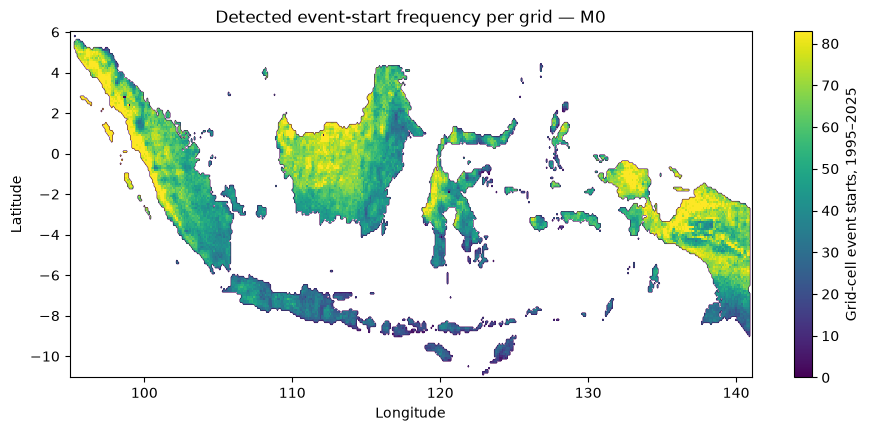

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_event_frequency_map_M1


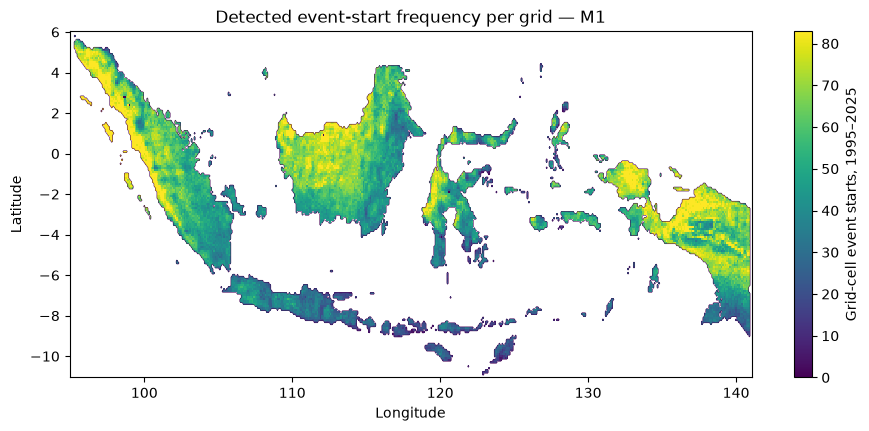

Figur tersimpan: D:\ERA5_LAND\output_fd_03_sensitivity\figure_event_frequency_map_M2


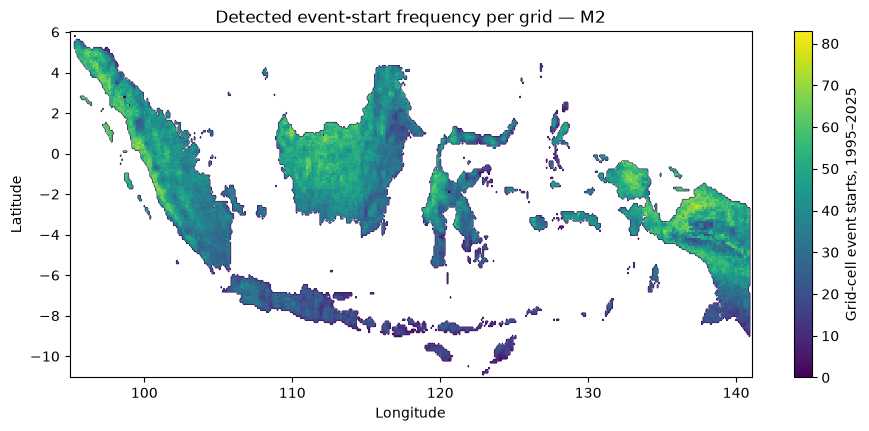

In [30]:
core_overlap = overlap_table[
    overlap_table["metric"] == "drought_core_spatiotemporal"
]
method_order = list(datasets.keys())
matrix = np.eye(len(method_order), dtype=float)
for _, row in core_overlap.iterrows():
    i = method_order.index(row["method_a"])
    j = method_order.index(row["method_b"])
    matrix[i, j] = matrix[j, i] = row["jaccard"]

fig, ax = plt.subplots(figsize=(5.5, 4.8))
image = ax.imshow(matrix, vmin=0, vmax=1)
ax.set_xticks(np.arange(len(method_order)), method_order)
ax.set_yticks(np.arange(len(method_order)), method_order)
ax.set(title="Spatiotemporal drought-core Jaccard overlap")
for i in range(len(method_order)):
    for j in range(len(method_order)):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Jaccard index")
save_figure(fig, "figure_drought_core_jaccard")
plt.show()

frequency_maps = {}
for method, dataset in datasets.items():
    frequency = (
        (dataset["fd_event_start"] == 1)
        .where(valid_grid, False)
        .sum("time_index")
        .compute()
    )
    frequency_maps[method] = frequency

shared_vmax = max(float(frequency.quantile(0.99)) for frequency in frequency_maps.values())
for method, frequency in frequency_maps.items():
    fig, ax = plt.subplots(figsize=(11, 4.5))
    mesh = ax.pcolormesh(
        frequency["longitude"],
        frequency["latitude"],
        frequency.where(valid_grid),
        shading="auto",
        vmin=0,
        vmax=shared_vmax,
    )
    ax.contour(
        valid_grid["longitude"],
        valid_grid["latitude"],
        valid_grid.astype(int),
        levels=[0.5],
        linewidths=0.4,
    )
    ax.set(
        xlabel="Longitude",
        ylabel="Latitude",
        title=f"Detected event-start frequency per grid — {method}",
    )
    fig.colorbar(mesh, ax=ax, label="Grid-cell event starts, 1995–2025")
    save_figure(fig, f"figure_event_frequency_map_{method}")
    plt.show()


## 24. Manifest dan ringkasan keluaran


In [31]:
manifest = {
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
    "notebook": "03_final_domain_sensitivity_flash_drought.ipynb",
    "period": "1995-2025",
    "notebook01_percentile_file": str(PERCENTILE_FILE),
    "notebook01_rzsm_file": str(RZSM_FILE),
    "m0_notebook02_file": str(M0_FILE_RESOLVED),
    "mask_source": str(mask_source),
    "valid_indonesia_grid_count": int(valid_grid.sum()),
    "ranking_excluded_years": RANKING_EXCLUDE_YEARS,
    "method_configs": METHOD_CONFIGS,
    "method_files": {method: str(path) for method, path in method_files.items()},
    "largest_core_cluster_calculated": CALCULATE_LARGEST_CORE_CLUSTER,
    "robust_top5_years": robust_top5_years,
}

MANIFEST_FILE = OUTPUT_DIR / "fd_sensitivity_manifest.json"
MANIFEST_FILE.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

output_files = sorted(OUTPUT_DIR.glob("*"))
print("Keluaran Notebook 03:")
for path in output_files:
    print("-", path.name)


Keluaran Notebook 03:
- fd_detection_M1_1995_2025_indonesia.nc
- fd_detection_M2_1995_2025_indonesia.nc
- fd_sensitivity_annual_metrics_1995_2025.csv
- fd_sensitivity_candidate_years.csv
- fd_sensitivity_distributions.csv
- fd_sensitivity_manifest.json
- fd_sensitivity_method_configuration.csv
- fd_sensitivity_overlap.csv
- fd_sensitivity_pentad_metrics_1995_2025.csv
- fd_sensitivity_qc_summary.csv
- fd_sensitivity_top10_years.csv
- figure_affected_grid_percent_by_method.pdf
- figure_affected_grid_percent_by_method.png
- figure_annual_maximum_drought_core_area.pdf
- figure_annual_maximum_drought_core_area.png
- figure_candidate_year_1997_core_area.pdf
- figure_candidate_year_1997_core_area.png
- figure_candidate_year_2003_core_area.pdf
- figure_candidate_year_2003_core_area.png
- figure_candidate_year_2004_core_area.pdf
- figure_candidate_year_2004_core_area.png
- figure_candidate_year_2015_core_area.pdf
- figure_candidate_year_2015_core_area.png
- figure_distribution_duration_pentads_

## 25. Cara membaca hasil sebelum Notebook 04

Gunakan tabel berikut sebagai dasar keputusan:

1. `fd_sensitivity_qc_summary.csv` — apakah jumlah event turun secara masuk akal dari M0 ke M1/M2?
2. `fd_sensitivity_top10_years.csv` — apakah tahun utama relatif stabil?
3. `fd_sensitivity_candidate_years.csv` — bagaimana posisi 1997, 2003, 2004, dan 2015?
4. `fd_sensitivity_overlap.csv` — seberapa besar event M1/M2 mempertahankan pola M0?
5. `fd_sensitivity_annual_metrics_1995_2025.csv` — statistik nasional final menggunakan mask Indonesia.

### Keputusan metodologis yang disarankan

- **M1** menjadi calon definisi utama karena menambahkan batas onset tanpa langsung mewajibkan persistence tiga pentad.
- **M2** menjadi uji sensitivitas yang lebih ketat terhadap rapid dry spell singkat.
- M0 dipertahankan sebagai broad screening.
- Jangan memilih metode berdasarkan metode mana yang menghasilkan tahun atau angka area paling besar. Pilih berdasarkan konsistensi definisi, QC, dan robustness hasil.
- Bila kandidat utama tetap berada pada kelompok teratas M1 dan M2, lanjutkan ke Notebook 04 untuk analisis precipitation, T2M, VPD, ET, ENSO, dan IOD.
